In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [3]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [4]:
adata.obs['annot_final'].value_counts()

GZMK+ CD8 T progenitor ex Cell    18794
T naive/early memory Cell         11080
Tactiv Cell                        8695
CD8 Tem Cell                       6819
Terminal CD8 Tex Cell              2542
CD8 HSP T cell                     2297
Tprolif Cell                       1854
Th17/Tc17                          1630
CD8 Cytotoxic T Cell                948
Tc17                                847
Name: annot_final, dtype: int64

In [63]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [64]:
adata = adata[adata.obs['annot_final'].isin([
 'CD8 Tem Cell',
 'Tactiv Cell',
 'GZMK+ CD8 T progenitor ex Cell',
 'Th17/Tc17',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'CD8 T naive/early memory Cell',
 'Tprolif Cell',
 'T naive/early memory Cell',
 'Terminal CD8 Tex Cell',
 'Tnaive Cell'
])]

In [65]:
adata.obs['annot_final'].value_counts()

GZMK+ CD8 T progenitor ex Cell    18794
T naive/early memory Cell         11080
Tactiv Cell                        8695
CD8 Tem Cell                       6819
Terminal CD8 Tex Cell              2542
CD8 HSP T cell                     2297
Tprolif Cell                       1854
Th17/Tc17                          1630
CD8 Cytotoxic T Cell                948
Tc17                                847
Name: annot_final, dtype: int64

In [66]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_48263/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [67]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [68]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# F1

In [69]:
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()
clonotypes_b = adata[adata.obs['timepoint'] == 'B'].obs['clonotype_patient'].unique().tolist()

In [70]:
new_f1_clonotypes = [i for i in clonotypes_f1 if i not in clonotypes_b]

In [71]:
clonotype_counts_f1 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F1') & (
    adata.obs['clonotype_patient'].isin(new_f1_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [72]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [73]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [74]:
f1_props = []
for i in clonotype_counts_f1.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f1_props.append(clonotype_counts_f1.loc[i,'clonotype_patient'] / f1_count)

In [75]:
clonotype_counts_f1_norm = pd.DataFrame({'F1' : f1_props},index=clonotype_counts_f1.index)

In [76]:
expanding_clones = [i for i in clonotype_counts_f1_norm.index if clonotype_counts_f1_norm.loc[i,'F1'] > 0]

In [77]:
len(expanding_clones)

11610

In [78]:
new_clones_f1 = expanding_clones

# F2

In [79]:
clonotypes_f2 = adata[adata.obs['timepoint'] == 'F2'].obs['clonotype_patient'].unique().tolist()
clonotypes_f1 = adata[adata.obs['timepoint'] == 'F1'].obs['clonotype_patient'].unique().tolist()

In [80]:
new_f2_clonotypes = [i for i in clonotypes_f2 if i not in clonotypes_f1]

In [81]:
clonotype_counts_f2 = pd.DataFrame(adata[(adata.obs['timepoint'] == 'F2') & (
    adata.obs['clonotype_patient'].isin(new_f2_clonotypes)
)].obs['clonotype_patient'].value_counts())

In [82]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [83]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [84]:
f2_props = []
for i in clonotype_counts_f2.index:
    temp = i.split('_')[1]
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f2_props.append(clonotype_counts_f2.loc[i,'clonotype_patient'] / f2_count)

In [85]:
clonotype_counts_f2_norm = pd.DataFrame({'F2' : f2_props},index=clonotype_counts_f2.index)

In [86]:
expanding_clones = [i for i in clonotype_counts_f2_norm.index if clonotype_counts_f2_norm.loc[i,'F2'] > 0]

In [87]:
len(clonotype_counts_f2_norm)

9599

In [88]:
len(expanding_clones)

9599

In [89]:
new_clones_f2 = expanding_clones

# Subsample

In [90]:
import random
temp_list = []
for i in adata.obs['sample_x'].unique():
    temp = adata[adata.obs['sample_x'] == i]
    if len(temp) < 100:
        temp_list.append(temp)
    else:
        subsample_obs = random.sample(temp.obs_names.tolist(), 100)
        temp_list.append(temp[subsample_obs,:])

In [91]:
import anndata as ad
subsample = ad.concat(temp_list)

In [92]:
f1_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(new_clones_f1) & (
        subsample.obs['progression'] == 'Slow'
    ) & (subsample.obs['timepoint'] == 'F1')].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(new_clones_f1) & (
        subsample.obs['progression'] == 'Fast'
    ) & (subsample.obs['timepoint'] == 'F1')].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

In [93]:
f1_counts

annot_final,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,GZMK+ CD8 T progenitor ex Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
timepoint,,,,,,,,,,
F1,15,30,122,472,454,297,29,58,101,72
F1,7,4,95,263,197,186,15,17,25,36


Text(0.5, 1.0, 'Phenotypic Distribution of\nNew F1 Clones, Subsampled')

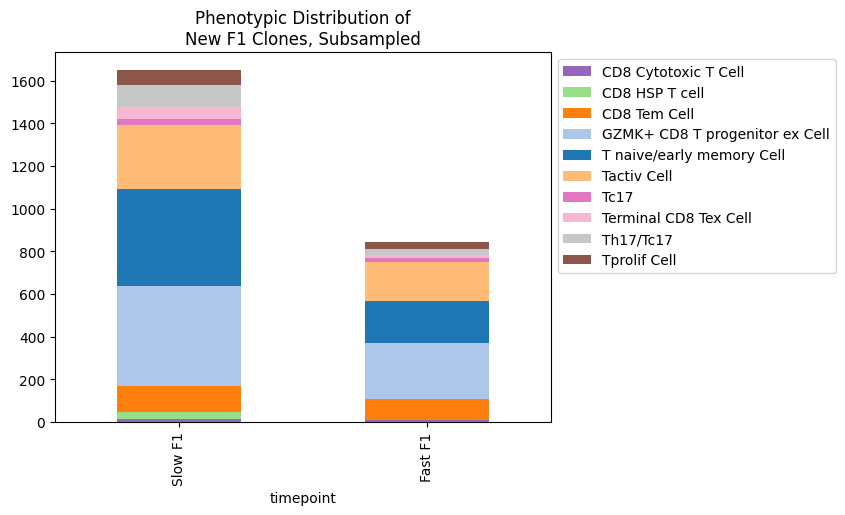

In [94]:
ax=f1_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Slow F1','Fast F1'])
ax.set_title('Phenotypic Distribution of\nNew F1 Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\nNew F1 Clones, Subsampled')

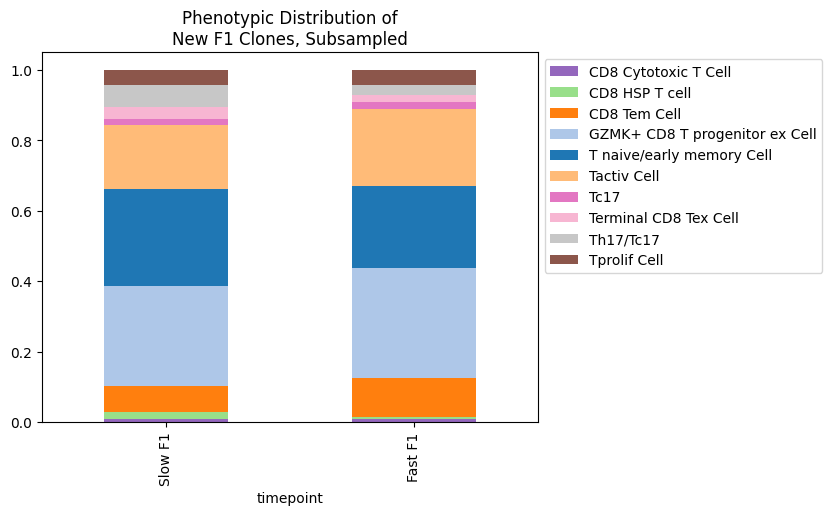

In [95]:
ax=f1_counts.div(f1_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Slow F1','Fast F1'])
ax.set_title('Phenotypic Distribution of\nNew F1 Clones, Subsampled')

In [96]:
f2_counts = pd.concat([
    subsample[
    subsample.obs['clonotype_patient'].isin(new_clones_f2) & (
        subsample.obs['progression'] == 'Slow'
    ) & (subsample.obs['timepoint'] == 'F2')].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0),
    subsample[
    subsample.obs['clonotype_patient'].isin(new_clones_f2) & (
        subsample.obs['progression'] == 'Fast'
    ) & (subsample.obs['timepoint'] == 'F2')].obs[
        ['annot_final','timepoint']
    ].value_counts().reset_index().pivot(
        columns='annot_final',index='timepoint',values=0).fillna(0)
]).fillna(0)

Text(0.5, 1.0, 'Phenotypic Distribution of\nNew F2 Clones, Subsampled')

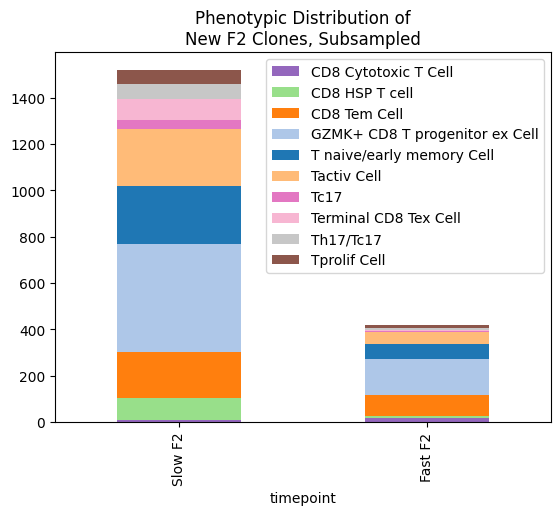

In [97]:
ax=f2_counts.plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Slow F2','Fast F2'])
ax.set_title('Phenotypic Distribution of\nNew F2 Clones, Subsampled')

Text(0.5, 1.0, 'Phenotypic Distribution of\nNew F2 Clones, Subsampled')

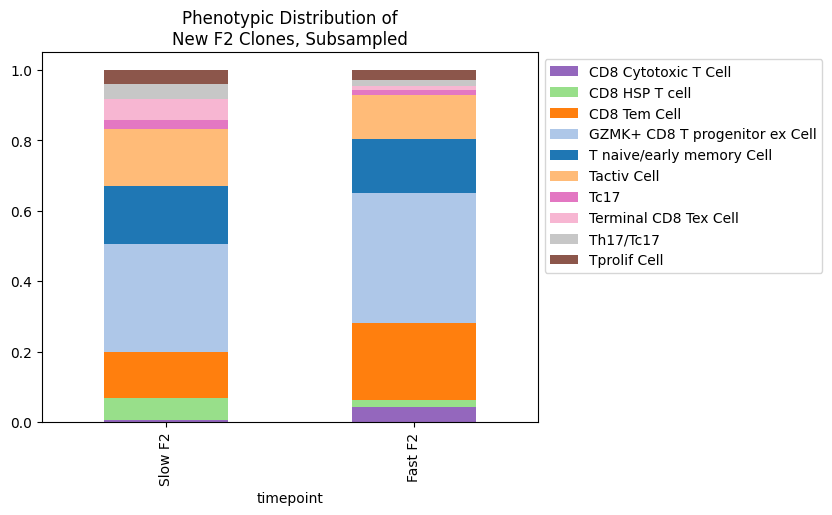

In [98]:
ax=f2_counts.div(f2_counts.sum(axis=1),axis=0).plot(
    kind='bar',stacked=True,color=color_dict)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xticklabels(['Slow F2','Fast F2'])
ax.set_title('Phenotypic Distribution of\nNew F2 Clones, Subsampled')

# Clonotype by clonotype

In [99]:
dist_f1_slow = adata[(adata.obs['clonotype_patient'].isin(
    new_clones_f1)) & (
    adata.obs['timepoint'] == 'F1'
    ) & (
    adata.obs['progression'] == 'Slow'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow.index = [i.split('_')[1] for i in dist_f1_slow.index]
dist_f1_slow = dist_f1_slow.groupby(dist_f1_slow.index).sum()
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f1_fast = adata[(adata.obs['clonotype_patient'].isin(
    new_clones_f1)) & (
    adata.obs['timepoint'] == 'F1'
    ) & (
    adata.obs['progression'] == 'Fast'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_fast.index = [i.split('_')[1] for i in dist_f1_fast.index]
dist_f1_fast = dist_f1_fast.groupby(dist_f1_fast.index).sum()
dist_f1_fast = dist_f1_fast.div(dist_f1_fast.sum(axis=1),axis=0)

In [100]:
dist_f2_slow = adata[(adata.obs['clonotype_patient'].isin(
    new_clones_f2)) & (
    adata.obs['timepoint'] == 'F2'
    ) & (
    adata.obs['progression'] == 'Slow'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow.index = [i.split('_')[1] for i in dist_f2_slow.index]
dist_f2_slow = dist_f2_slow.groupby(dist_f2_slow.index).sum()
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

dist_f2_fast = adata[(adata.obs['clonotype_patient'].isin(
    new_clones_f2)) & (
    adata.obs['timepoint'] == 'F2'
    ) & (
    adata.obs['progression'] == 'Fast'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_fast.index = [i.split('_')[1] for i in dist_f2_fast.index]
dist_f2_fast = dist_f2_fast.groupby(dist_f2_fast.index).sum()
dist_f2_fast = dist_f2_fast.div(dist_f2_fast.sum(axis=1),axis=0)

In [101]:
dist_f2_fast.columns.tolist()

['CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'CD8 Tem Cell',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Tactiv Cell',
 'Tc17',
 'Terminal CD8 Tex Cell',
 'Th17/Tc17',
 'Tprolif Cell']

In [102]:
dist_f1_slow.columns.tolist()

['CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'CD8 Tem Cell',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Tactiv Cell',
 'Tc17',
 'Terminal CD8 Tex Cell',
 'Th17/Tc17',
 'Tprolif Cell']

In [103]:
dist_f1_slow = dist_f1_slow[[
    'GZMK+ CD8 T progenitor ex Cell','CD8 Cytotoxic T Cell', 'CD8 HSP T cell',
                'CD8 Tem Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]
dist_f1_fast = dist_f1_fast[[
    'GZMK+ CD8 T progenitor ex Cell','CD8 Cytotoxic T Cell', 'CD8 HSP T cell',
                  'CD8 Tem Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]
dist_f2_slow = dist_f2_slow[[
    'GZMK+ CD8 T progenitor ex Cell','CD8 Cytotoxic T Cell', 'CD8 HSP T cell',
                  'CD8 Tem Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]
dist_f2_fast = dist_f2_fast[[
    'GZMK+ CD8 T progenitor ex Cell','CD8 Cytotoxic T Cell', 'CD8 HSP T cell',
                  'CD8 Tem Cell',
                  'T naive/early memory Cell', 'Tactiv Cell', 'Tc17',
                  'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell']]

In [104]:
dist_f1_slow

annot_final,GZMK+ CD8 T progenitor ex Cell,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
E12,0.183852,0.035019,0.023346,0.027237,0.143969,0.140078,0.006809,0.356031,0.029183,0.054475
E15,0.213389,0.018131,0.002789,0.101813,0.214784,0.096234,0.018131,0.273361,0.034868,0.026499
E17,0.424157,0.005618,0.008427,0.191011,0.137640,0.064607,0.008427,0.000000,0.022472,0.137640
E18,0.292593,0.000926,0.009259,0.001852,0.573148,0.076852,0.002778,0.000000,0.009259,0.033333
E20,0.278043,0.009547,0.005967,0.010740,0.552506,0.072792,0.001193,0.000000,0.013126,0.056086
E21,0.203034,0.002334,0.003501,0.029172,0.451575,0.108518,0.024504,0.000000,0.151692,0.025671
E22,0.275813,0.004243,0.004243,0.236209,0.292786,0.125884,0.005658,0.018388,0.029703,0.007072
E23,0.720930,0.005367,0.003578,0.000000,0.037567,0.139535,0.000000,0.000000,0.033989,0.059034
E24,0.312500,0.022115,0.004808,0.250962,0.257692,0.116346,0.004808,0.000962,0.014423,0.015385
E26,0.407125,0.002545,0.000000,0.083969,0.320611,0.119593,0.012723,0.000000,0.038168,0.015267


In [105]:
dist_f2_fast

annot_final,GZMK+ CD8 T progenitor ex Cell,CD8 Cytotoxic T Cell,CD8 HSP T cell,CD8 Tem Cell,T naive/early memory Cell,Tactiv Cell,Tc17,Terminal CD8 Tex Cell,Th17/Tc17,Tprolif Cell
E16,0.718720,0.056256,0.004850,0.043647,0.078565,0.067895,0.002910,0.001940,0.003880,0.021339
E25,0.537255,0.105882,0.027451,0.023529,0.074510,0.129412,0.011765,0.015686,0.007843,0.066667
E27,0.000000,0.000000,0.000000,0.555556,0.111111,0.222222,0.000000,0.000000,0.000000,0.111111
E30,0.028056,0.002004,0.026052,0.559118,0.082164,0.298597,0.000000,0.000000,0.004008,0.000000
E31,0.133333,0.028571,0.028571,0.342857,0.247619,0.057143,0.066667,0.028571,0.047619,0.019048
E44,0.288000,0.000000,0.040000,0.328000,0.224000,0.072000,0.016000,0.008000,0.016000,0.008000
E45,0.090909,0.000000,0.000000,0.045455,0.045455,0.590909,0.000000,0.000000,0.045455,0.181818


Text(0.5, 1.0, 'Per patient distribution of new clonotypes, Slow F1')

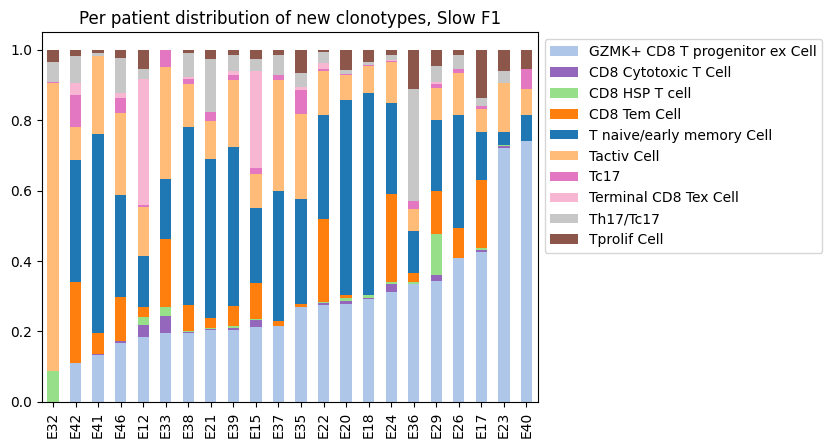

In [106]:
dist_f1_slow.sort_values(by='GZMK+ CD8 T progenitor ex Cell').plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Per patient distribution of new clonotypes, Slow F1')

Text(0.5, 1.0, 'Per patient distribution of new clonotypes, Fast F1')

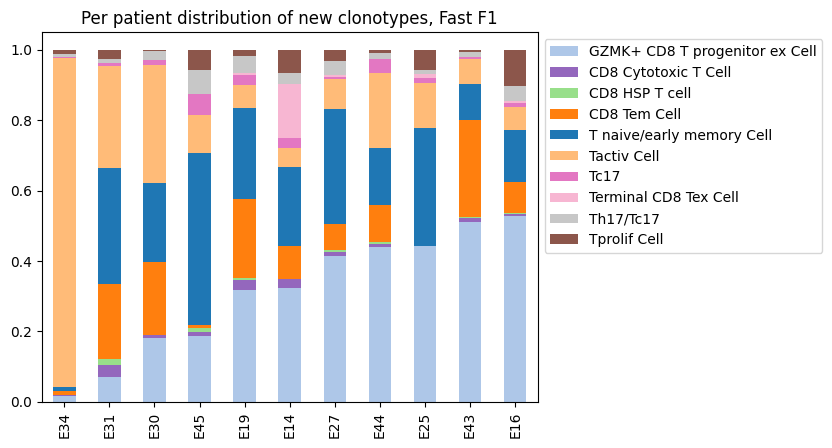

In [107]:
dist_f1_fast.sort_values(by='GZMK+ CD8 T progenitor ex Cell').plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Per patient distribution of new clonotypes, Fast F1')

Text(0.5, 1.0, 'Per patient distribution of new clonotypes, Slow F2')

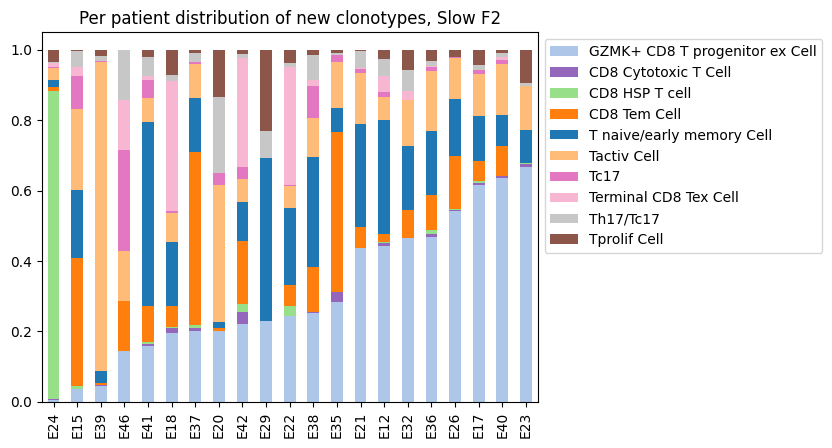

In [108]:
dist_f2_slow.sort_values(by='GZMK+ CD8 T progenitor ex Cell').plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Per patient distribution of new clonotypes, Slow F2')

Text(0.5, 1.0, 'Per patient distribution of new clonotypes, Fast F2')

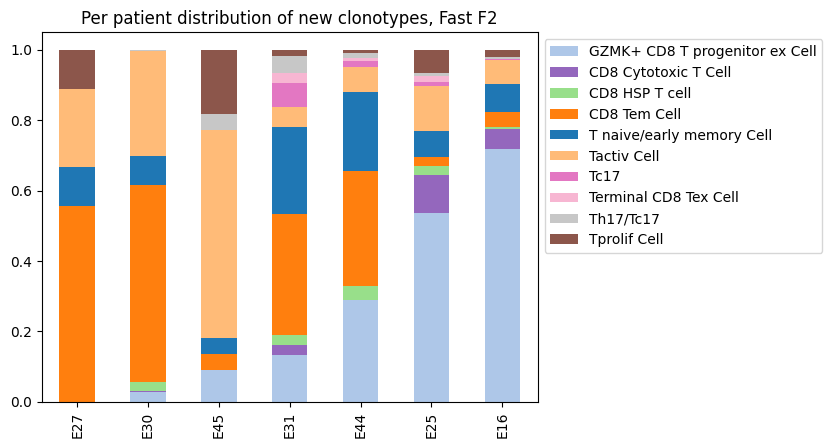

In [109]:
dist_f2_fast.sort_values(by='GZMK+ CD8 T progenitor ex Cell').plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Per patient distribution of new clonotypes, Fast F2')